In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [ ]:
df = pd.read_csv("D:\\Heart_Disease_EDA_Project\\data\\heart.csv")
df.rename(columns={
    'age': 'Age',
    'sex': 'Gender',
    'cp': 'ChestPainType',
    'trestbps': 'RestingBP',
    'chol': 'Cholesterol',
    'fbs': 'FastingBloodSugar',
    'restecg': 'RestingECG',
    'thalach': 'MaxHeartRate',
    'exang': 'ExerciseAngina',
    'oldpeak': 'ST_Depression',
    'slope': 'ST_Slope',
    'ca': 'MajorVessels',
    'thal': 'Thalassemia',
    'target': 'HeartDisease'
}, inplace=True)

df.head()

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBloodSugar,RestingECG,MaxHeartRate,ExerciseAngina,ST_Depression,ST_Slope,MajorVessels,Thalassemia,HeartDisease
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.isnull().sum()

Age                  0
Gender               0
ChestPainType        0
RestingBP            0
Cholesterol          0
FastingBloodSugar    0
RestingECG           0
MaxHeartRate         0
ExerciseAngina       0
ST_Depression        0
ST_Slope             0
MajorVessels         0
Thalassemia          0
HeartDisease         0
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                302 non-null    int64  
 1   Gender             302 non-null    int64  
 2   ChestPainType      302 non-null    int64  
 3   RestingBP          302 non-null    int64  
 4   Cholesterol        302 non-null    int64  
 5   FastingBloodSugar  302 non-null    int64  
 6   RestingECG         302 non-null    int64  
 7   MaxHeartRate       302 non-null    int64  
 8   ExerciseAngina     302 non-null    int64  
 9   ST_Depression      302 non-null    float64
 10  ST_Slope           302 non-null    int64  
 11  MajorVessels       302 non-null    int64  
 12  Thalassemia        302 non-null    int64  
 13  HeartDisease       302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [9]:
df.describe()

,Age,Gender,ChestPainType,RestingBP,Cholesterol,FastingBloodSugar,RestingECG,MaxHeartRate,ExerciseAngina,ST_Depression,ST_Slope,MajorVessels,Thalassemia,HeartDisease
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


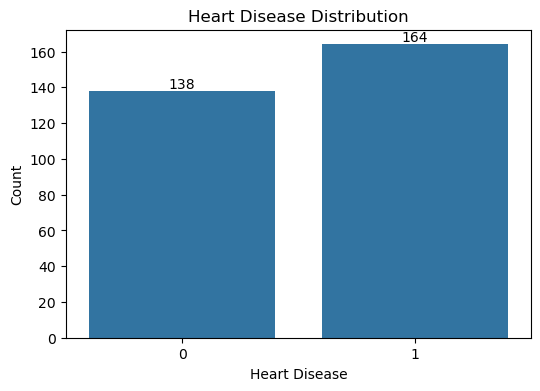

In [10]:
#Check Target Distribution

plt.figure(figsize=(6,4))

ax = sns.countplot(x='HeartDisease', data=df)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

Insight:

HeartDisease = 1 indicates the presence of heart disease.

HeartDisease = 0 indicates the absence of heart disease.

The distribution of patients with and without heart disease is relatively balanced, with a slightly higher number of patients diagnosed with heart disease. This balanced distribution is beneficial for machine learning model training as it reduces the risk of class imbalance.

Approximate counts:

HeartDisease = 0 → 138 patients

HeartDisease = 1 → 164 patients

Total = 302 patients

Approximately 54% of patients have heart disease, while 46% do not.

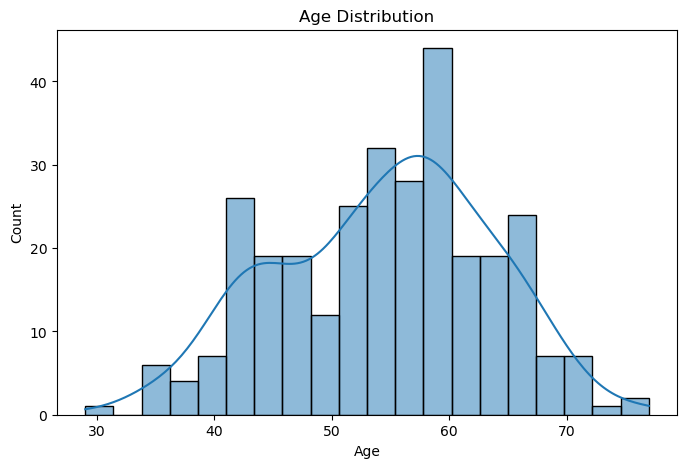

In [11]:
#Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

Insight:

The majority of patients in the dataset fall within the age range of 50–65 years, indicating that heart disease analysis is primarily focused on middle-aged and older adults.

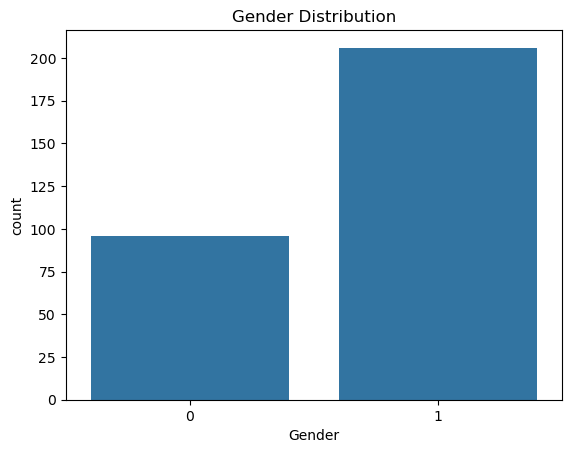

In [12]:
#Gender Distribution
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

Insight:

0 = Female

1 = Male

Male patients constitute a significantly larger portion of the dataset compared to female patients, which may influence the model's learning patterns and predictions.

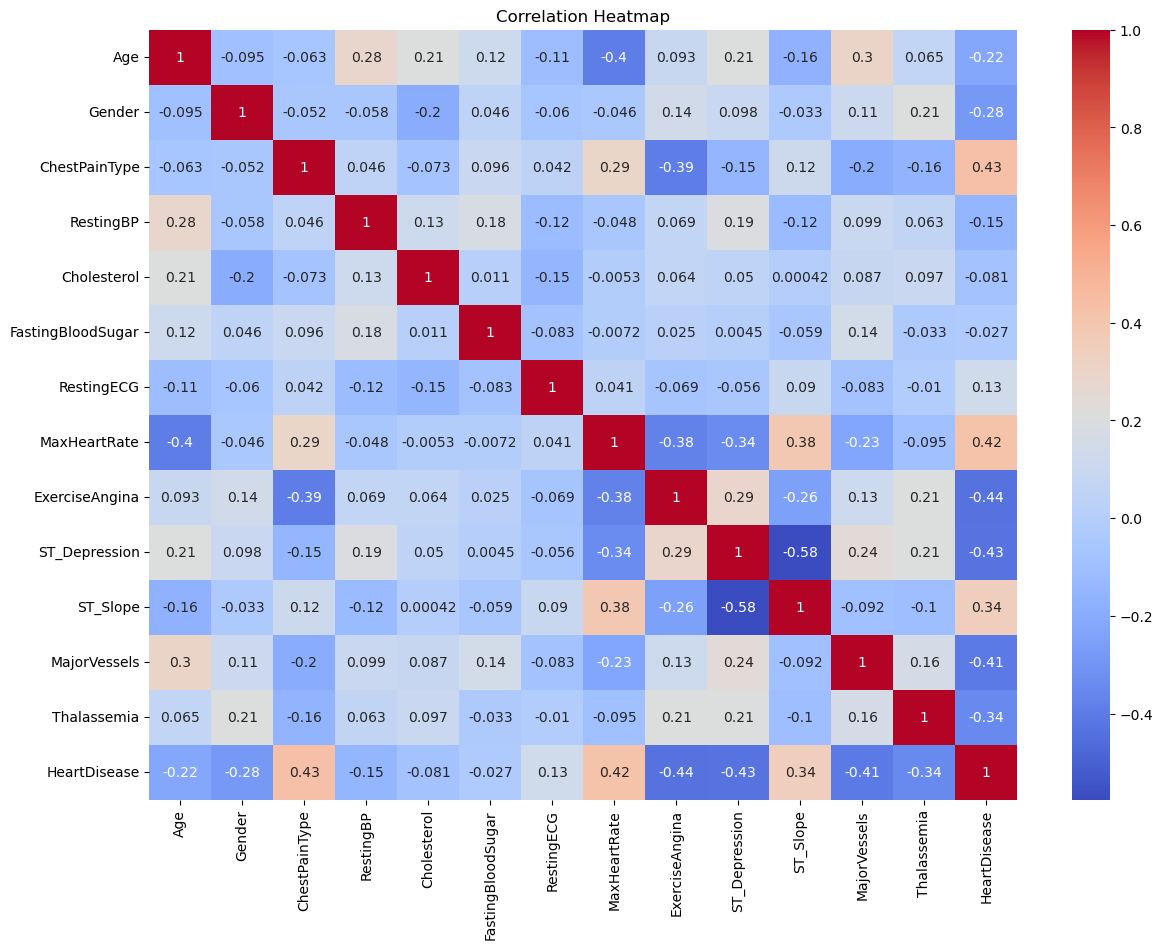

In [13]:
#Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Correlation Heatmap Insights

Strong Positive Correlations with Heart Disease

Feature	Correlation

ChestPainType	+0.43

MaxHeartRate	+0.42

ST_Slope	+0.34

Insight:

ChestPainType (+0.43) and MaxHeartRate (+0.42) show the strongest positive correlation with heart disease. This indicates that these factors play an important role in predicting whether a patient has heart disease. ST_Slope (+0.34) also contributes positively to prediction.


Strong Negative Correlations with Heart Disease

Feature	Correlation

ExerciseAngina	-0.44

ST_Depression	-0.43

MajorVessels	-0.41

Thalassemia	-0.34


Insight:

ExerciseAngina (-0.44), ST_Depression (-0.43), MajorVessels (-0.41), and Thalassemia (-0.34) exhibit strong negative correlations with heart disease. These variables are likely to be important predictors in the machine learning model.


Moderate Correlations

Feature	Correlation

Gender	-0.28

Age	-0.22


Insight:

Age and Gender show moderate relationships with heart disease. While they may influence prediction, they are less significant than clinical measurements such as chest pain type, heart rate, and ST segment characteristics.


Weak or Negligible Correlations

Feature	Correlation

Cholesterol	-0.081

FastingBloodSugar	-0.027

RestingECG	+0.13

RestingBP	-0.15


Insight:

Cholesterol, Fasting Blood Sugar, Resting ECG, and Resting Blood Pressure demonstrate weak correlations with heart disease in this dataset. These variables alone may not be strong indicators but can still contribute when combined with other features.


Interesting Relationships Between Features

Age vs MaxHeartRate

Correlation = -0.40

Insight:

As age increases, the maximum heart rate achieved tends to decrease. This inverse relationship aligns with known physiological trends.

ST_Depression vs ST_Slope

Correlation = -0.58

Insight:

ST_Depression and ST_Slope show a strong negative correlation, suggesting that changes in one variable are associated with opposite changes in the other. This may indicate overlapping cardiovascular information.

ChestPainType vs ExerciseAngina

Correlation = -0.39

Insight:

Chest pain type and exercise-induced angina exhibit a moderate negative relationship, indicating that different chest pain categories may be associated with varying levels of exercise-induced symptoms.

Conclusion for Report

The correlation analysis reveals that ChestPainType, MaxHeartRate, ExerciseAngina, ST_Depression, MajorVessels, and ST_Slope are the most influential features associated with heart disease prediction. These variables are expected to contribute significantly to the performance of machine learning models developed in subsequent stages of the project.

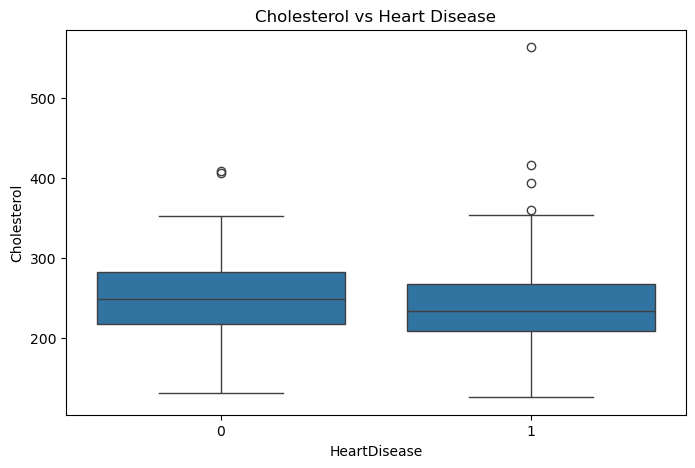

In [14]:
#Cholesterol Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x='HeartDisease',
    y='Cholesterol',
    data=df
)

plt.title("Cholesterol vs Heart Disease")
plt.show()

Insight:

Cholesterol levels show substantial overlap between patients with and without heart disease. The median cholesterol values are similar across both groups, suggesting that cholesterol alone is not a strong predictor of heart disease in this dataset. Several outliers are present, indicating unusually high cholesterol levels for some patients.

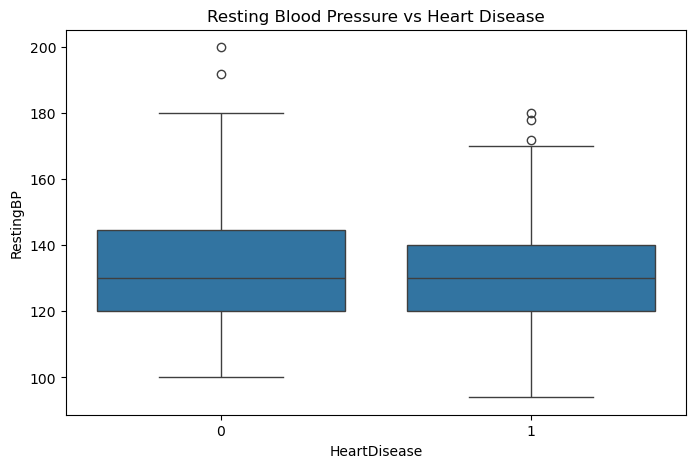

In [15]:
#Blood Pressure Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x='HeartDisease',
    y='RestingBP',
    data=df
)

plt.title("Resting Blood Pressure vs Heart Disease")
plt.show()

Insight:

Resting blood pressure distributions are similar for both heart disease groups. Although slight differences exist, the large overlap suggests that resting blood pressure alone may not effectively distinguish patients with heart disease from those without it.

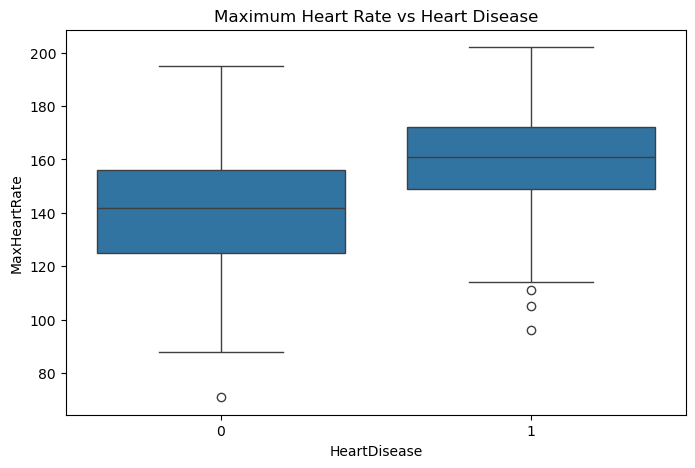

In [16]:
#Maximum Heart Rate Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    x='HeartDisease',
    y='MaxHeartRate',
    data=df
)

plt.title("Maximum Heart Rate vs Heart Disease")
plt.show()

Insight:

Patients with heart disease generally achieve higher maximum heart rates compared to those without heart disease. The visible separation between the distributions suggests that maximum heart rate is an important feature for heart disease prediction.

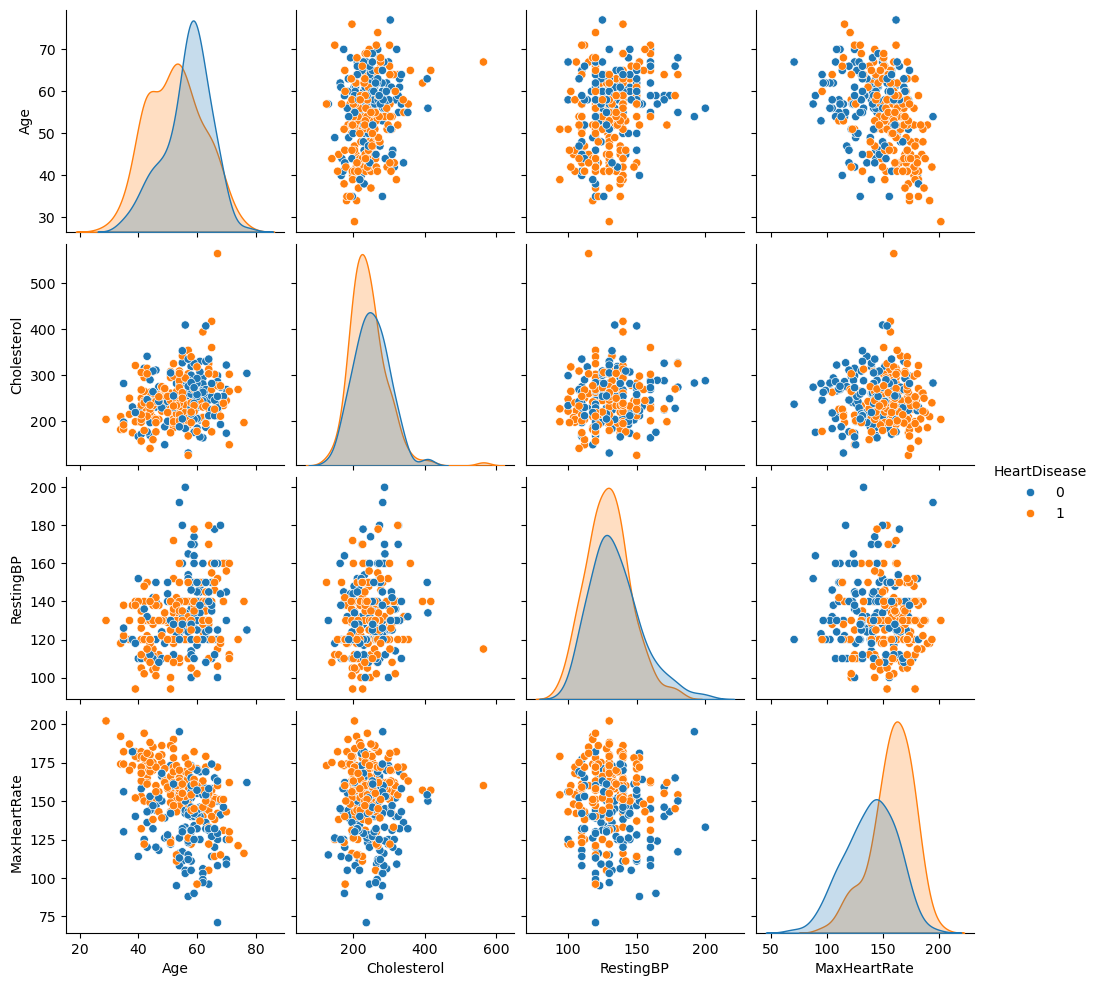

In [17]:
#Pairplot 
important_cols = [
    'Age',
    'Cholesterol',
    'RestingBP',
    'MaxHeartRate',
    'HeartDisease'
]

sns.pairplot(
    df[important_cols],
    hue='HeartDisease'
)

plt.show()

1. Age vs MaxHeartRate

Observation:

As age increases, maximum heart rate tends to decrease.

Insight:

A negative relationship exists between Age and MaxHeartRate, indicating that older patients generally achieve lower maximum heart rates. This observation is consistent with physiological expectations.

2. Heart Disease vs MaxHeartRate

Observation:

The orange points (HeartDisease = 1) are concentrated at higher MaxHeartRate values.

Insight:

MaxHeartRate shows noticeable separation between heart disease classes, making it one of the most influential variables for prediction.

3. Cholesterol vs Heart Disease

Observation:

Blue and orange points are highly mixed.

Insight:

Cholesterol values are widely distributed across both heart disease classes, indicating limited discriminatory power when used alone.

4. RestingBP vs Heart Disease

Observation:

Strong overlap between the classes.

Insight:

Resting blood pressure does not show a clear separation between patients with and without heart disease, suggesting a relatively weak individual relationship with the target variable.

5. Overall Dataset Pattern

Observation:

No single feature perfectly separates the two classes.

Insight:

The pairplot indicates that heart disease prediction cannot rely on a single variable. Instead, multiple clinical features must be combined through machine learning models to achieve accurate predictions.



Conclusion:

Exploratory Data Analysis revealed that MaxHeartRate, ChestPainType, ExerciseAngina, ST_Depression, and MajorVessels are among the most influential variables associated with heart disease. Cholesterol and Resting Blood Pressure demonstrated weaker individual relationships with the target variable. The pairplot further showed that no single feature can completely separate patients with and without heart disease, emphasizing the need for machine learning algorithms that combine multiple clinical indicators for accurate prediction.